## E-Commerce Sales Analysis

## Project Overview

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('ecommerce_sales_cleaned.csv')

data.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,calculated_revenue,revenue_check,month,delivery_group
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,1883.1960,OK,2022-01,7+ Days
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,304.1038,OK,2022-01,5-6 Days
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,644.3496,OK,2022-01,5-6 Days
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2569.9030,OK,2022-01,5-6 Days
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,468.5645,OK,2022-01,3-4 Days


## 1. Exploratory Data Analysis (EDA)

In [145]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            5000 non-null   int64  
 1   order_date          5000 non-null   str    
 2   customer_id         5000 non-null   int64  
 3   product_category    5000 non-null   str    
 4   region              5000 non-null   str    
 5   quantity            5000 non-null   int64  
 6   unit_price          5000 non-null   float64
 7   discount            5000 non-null   float64
 8   payment_method      5000 non-null   str    
 9   delivery_days       5000 non-null   int64  
 10  customer_rating     5000 non-null   float64
 11  revenue             5000 non-null   float64
 12  calculated_revenue  5000 non-null   float64
 13  revenue_check       5000 non-null   str    
 14  month               5000 non-null   str    
 15  delivery_group      5000 non-null   str    
dtypes: float64(5), in

In [146]:
data.describe()


,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue,calculated_revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148,1021.955177
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219,825.584221
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000,11.211000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500,354.528300
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000,796.650600
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000,1515.691125
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000,4119.330600


In [147]:
data.isnull().sum()


order_id              0
order_date            0
customer_id           0
product_category      0
region                0
quantity              0
unit_price            0
discount              0
payment_method        0
delivery_days         0
customer_rating       0
revenue               0
calculated_revenue    0
revenue_check         0
month                 0
delivery_group        0
dtype: int64

In [148]:
data.duplicated().sum()


np.int64(0)

In [149]:
data.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue', 'calculated_revenue', 'revenue_check',
       'month', 'delivery_group'],
      dtype='str')

## 3. Sales Performance

### 3.1 Total Revenue

In [150]:


print(((data["revenue"].sum()/data["order_id"].count())))

1021.955148


### 3.2 Monthly Revenue

In [151]:
data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.to_period("M")
data.head()


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,calculated_revenue,revenue_check,month,delivery_group
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,1883.1960,OK,2022-01,7+ Days
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,304.1038,OK,2022-01,5-6 Days
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,644.3496,OK,2022-01,5-6 Days
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2569.9030,OK,2022-01,5-6 Days
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,468.5645,OK,2022-01,3-4 Days


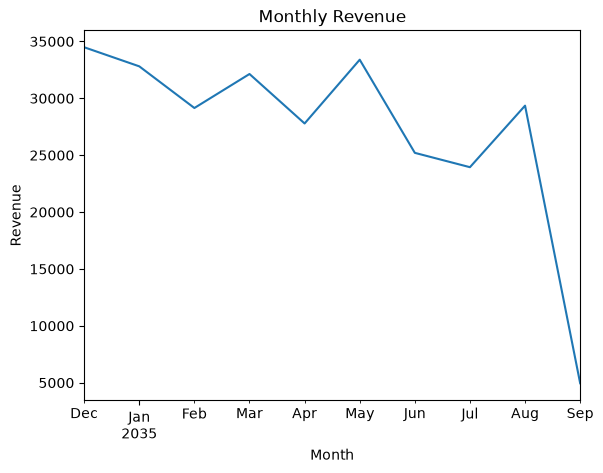

In [154]:
# monthly_revenue.plot(kind="line")
data.groupby("month")["revenue"].sum().tail(10).plot(kind="line")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

### 3.3 Revenue Growth %

In [152]:
monthly_revenue = data.groupby("month")["revenue"].sum()
monthly_growth = monthly_revenue.pct_change() * 100

monthly_analysis = pd.DataFrame({
    "Revenue": monthly_revenue,
    "Growth %": monthly_growth
})

monthly_analysis

,Revenue,Growth %
month,,
2022-01,35624.89,NaN
2022-02,29908.89,-16.044962
2022-03,30309.28,1.338699
2022-04,30781.96,1.559522
2022-05,41629.24,35.239082
...,...,...
2035-05,33393.87,20.172670
2035-06,25205.26,-24.521297
2035-07,23944.48,-5.002051


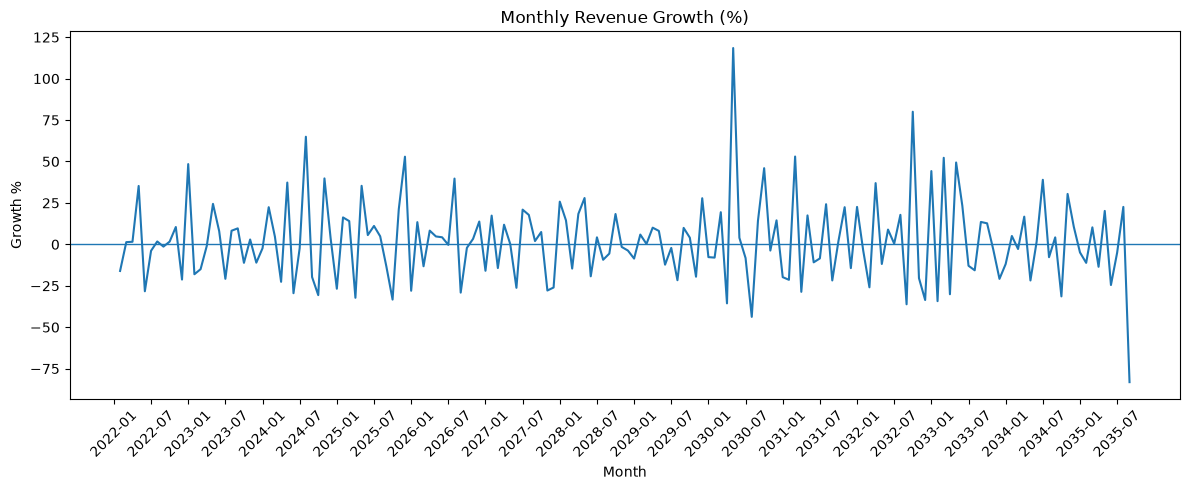

In [153]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_growth.index.astype(str),
    monthly_growth.values
)

plt.title("Monthly Revenue Growth (%)")
plt.xlabel("Month")
plt.ylabel("Growth %")

plt.xticks(
    range(0, len(monthly_growth), 6),
    monthly_growth.index.astype(str)[::6],
    rotation=45
)

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

### 3.4 Revenue by Category

In [155]:
catigory_revenue=data.groupby("product_category")["revenue"].sum()
catigory_revenue

product_category
Beauty          765860.88
Clothing       1531931.72
Electronics    1829899.22
Home            982083.92
Name: revenue, dtype: float64

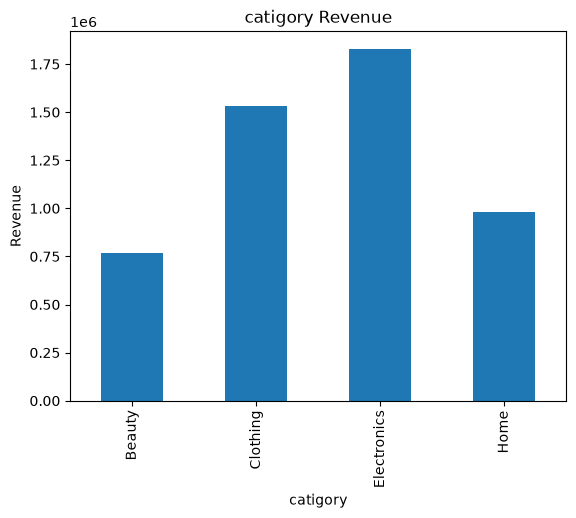

In [157]:
catigory_revenue.plot(kind="bar")
plt.title("catigory Revenue")
plt.xlabel("catigory")
plt.ylabel("Revenue")
plt.show()


### 3.5 AOV by Category

In [156]:
aov_category = (
    data.groupby("product_category")["revenue"]
    .sum()
    / data.groupby("product_category")["order_id"].nunique()
)

aov_category.sort_values(ascending=False)

product_category
Beauty         1059.281992
Electronics    1029.768835
Home           1013.502497
Clothing       1000.608570
dtype: float64

### 3.6 Revenue by Region

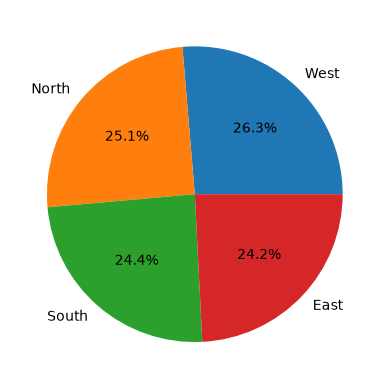

In [158]:
region_revenue=data.groupby("region")["revenue"].sum().sort_values(ascending=False)
region_revenue.plot(kind="pie", autopct="%1.1f%%")
plt.show()


## 4. Revenue Drivers

### 4.1 Quantity vs Revenue

In [159]:
quantity_revenue = (
    data.groupby("product_category")
    .agg(
        Total_Quantity=("quantity", "sum"),
        Total_Revenue=("revenue", "sum")
    )
    .sort_values("Total_Revenue", ascending=False)
)

quantity_revenue

,Total_Quantity,Total_Revenue
product_category,,
Electronics,7109,1829899.22
Clothing,6171,1531931.72
Home,3949,982083.92
Beauty,2995,765860.88


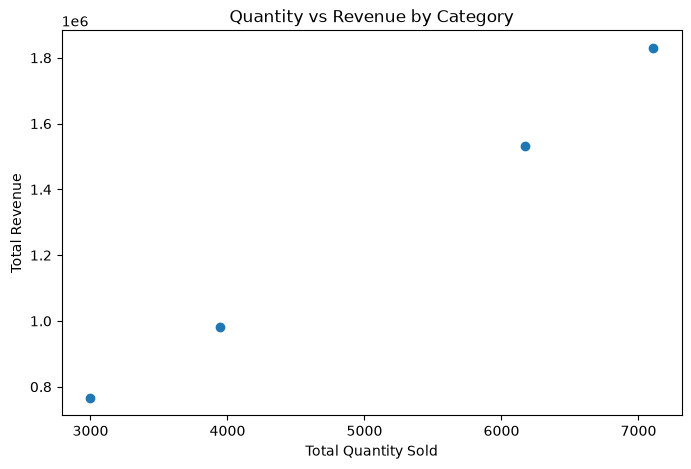

In [160]:
plt.figure(figsize=(8,5))

plt.scatter(
    quantity_revenue["Total_Quantity"],
    quantity_revenue["Total_Revenue"]
)

plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue")
plt.title("Quantity vs Revenue by Category")

plt.show()

### 4.2 Discount Analysis

In [177]:
average_discount = data["discount"].mean()

print(f"Average Discount: {average_discount:.2f}%")
data["discount_status"] = data["discount"].apply(
    lambda x: "No Discount" if x == 0 else "With Discount"
)
discount_analysis = (
    data.groupby("discount_status")
    .agg(
        Orders=("order_id", "nunique"),
        Revenue=("revenue", "sum"),
        Average_Order_Value=("revenue", "mean")
    )
)

discount_analysis

Average Discount: 0.18%


,Orders,Revenue,Average_Order_Value
discount_status,,,
No Discount,68,81686.86,1201.277353
With Discount,4932,5028088.88,1019.482741


## 5. Customer Behavior

In [173]:
total_customers = data["customer_id"].nunique()

total_customers

989

### 5.1 Customer Revenue

In [161]:
customer_revenue = data.groupby("customer_id")["revenue"].sum().sort_values(ascending=False)
customer_revenue.head(10)



customer_id
1663    17680.69
1955    16265.15
1675    15036.46
1276    15023.71
1647    14894.97
1804    14330.98
1193    14151.65
1836    14110.78
1957    13956.95
1735    13146.25
Name: revenue, dtype: float64

### 5.2 New vs Returning Customers

In [163]:
orders_per_customer = data.groupby("customer_id")["order_id"].nunique()

new_customers = (orders_per_customer == 1).sum()
new_customers
returning_customers = (orders_per_customer > 1).sum()
returning_customers

np.int64(950)

## 6. Operations & Customer Satisfaction

### 6.1 Average Delivery Time

In [164]:
delivery_days_average=data["delivery_days"].sum()/data["delivery_days"].count()

### 6.2 Delivery Time by Region

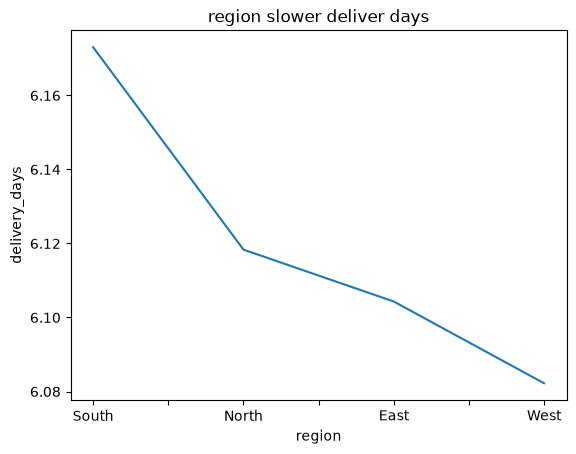

region
South    6.173013
North    6.118339
East     6.104319
West     6.082234
Name: delivery_days, dtype: float64

In [165]:
region_delivery_days =data.groupby("region")["delivery_days"].mean().sort_values(ascending=False)
region_delivery_days.plot(kind="line")
plt.title("region slower deliver days")
plt.xlabel("region")
plt.ylabel("delivery_days")
plt.show()
region_delivery_days



### 6.3 Delivery Time vs Customer Rating

In [166]:
data[["delivery_days", "customer_rating"]].corr()

,delivery_days,customer_rating
delivery_days,1.000000,-0.017625
customer_rating,-0.017625,1.000000


In [167]:
data["delivery_group"] = pd.cut(
    data["delivery_days"],
    bins=[0, 2, 4, 6, float("inf")],
    labels=["1-2 Days", "3-4 Days", "5-6 Days", "7+ Days"]
)
delivery_rating = (
    data.groupby("delivery_group", observed=True)["customer_rating"]
    .mean()
)

delivery_rating

delivery_group
1-2 Days    2.962731
3-4 Days    3.006448
5-6 Days    3.000895
7+ Days     2.955725
Name: customer_rating, dtype: float64

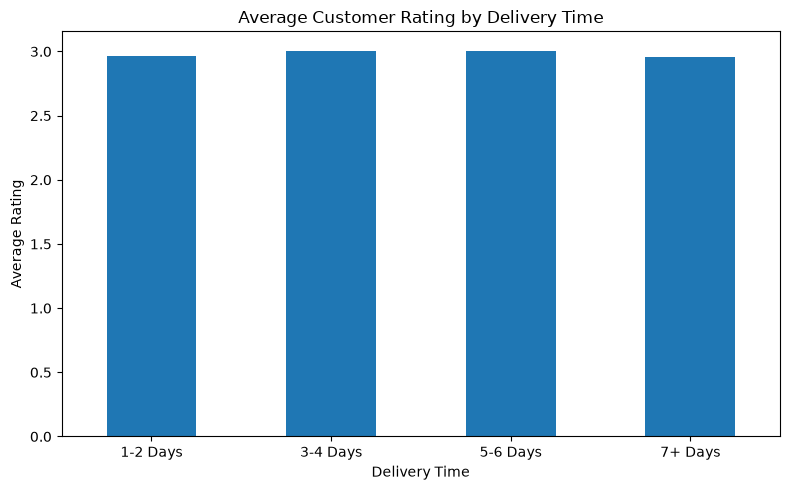

In [168]:
plt.figure(figsize=(8, 5))

delivery_rating.plot(kind="bar")

plt.title("Average Customer Rating by Delivery Time")
plt.xlabel("Delivery Time")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 6.5 Customer Rating by Region

In [172]:
region_rating = (
    data.groupby("region", observed=True)["customer_rating"]
    .mean()
)

region_rating

region
East     2.973187
North    2.993182
South    2.967798
West     2.961521
Name: customer_rating, dtype: float64

## 7. Payment Behavior

### 7.1 Payment Method Usage

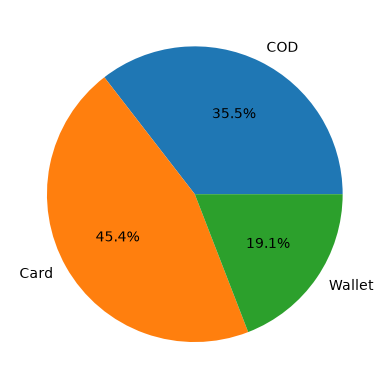

In [169]:
most_used_payment_method=data.groupby("payment_method")["customer_id"].count()
most_used_payment_method.plot(kind="pie", autopct="%1.1f%%")
plt.show()

### 7.2 Average Order Value by Payment Method

In [170]:
payment_revenue = (
    data.groupby("payment_method")["revenue"]
    .mean()
    .sort_values(ascending=False)
)

payment_revenue

payment_method
Card      1042.400088
COD       1008.122007
Wallet     999.078556
Name: revenue, dtype: float64

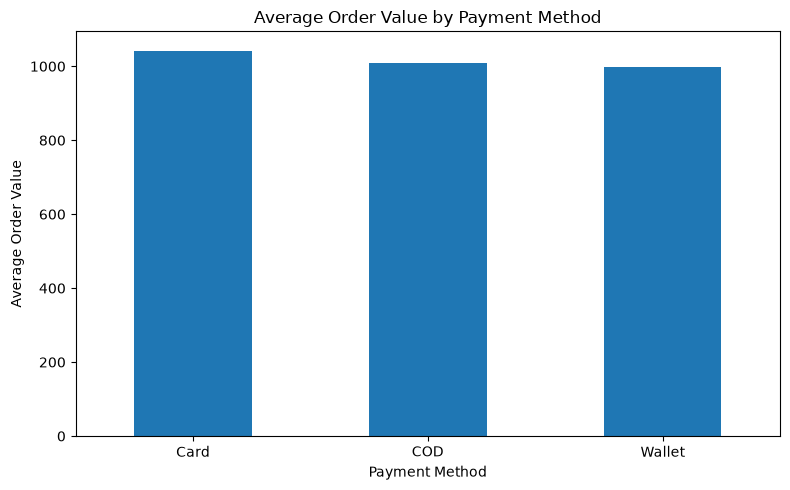

In [171]:
plt.figure(figsize=(8, 5))

payment_revenue.plot(kind="bar")

plt.title("Average Order Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Order Value")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [174]:
# data["discount"] = data["discount"].str.strip().replace("-", "0").astype(float)
# data["discount"].dtype

## 8. Correlation Analysis

### 8.1 Correlation Matrix

In [179]:
numeric_data = data[
    [
        "quantity",
        "unit_price",
        "discount",
        "delivery_days",
        "customer_rating",
        "revenue"
    ]
]
correlation_matrix = numeric_data.corr()

correlation_matrix

,quantity,unit_price,discount,delivery_days,customer_rating,revenue
quantity,1.000000,0.001498,-0.004302,-0.008748,0.019168,0.623564
unit_price,0.001498,1.000000,0.013215,0.015623,0.005025,0.678032
discount,-0.004302,0.013215,1.000000,-0.000382,0.012776,-0.139296
delivery_days,-0.008748,0.015623,-0.000382,1.000000,-0.017625,0.005444
customer_rating,0.019168,0.005025,0.012776,-0.017625,1.000000,0.012446
revenue,0.623564,0.678032,-0.139296,0.005444,0.012446,1.000000


### 8.2 Correlation Heatmap

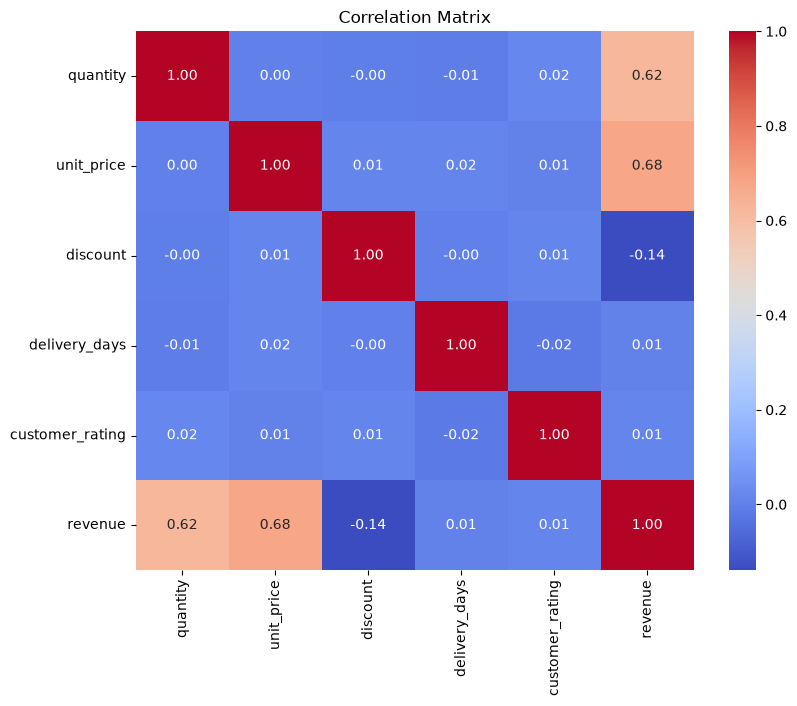

In [180]:
plt.figure(figsize=(9,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
# data.to_csv(
#     "ecommerce_sales_cleaned.csv",
#     index=False
# )

## 9. Key Insights

- The dataset contains 5,000 orders and 989 unique customers, with total revenue of approximately 5.11 million.

- Electronics generated the highest total revenue at approximately 1.83 million, followed by Clothing at 1.53 million.

- Beauty had the highest Average Order Value (AOV) among the product categories at approximately 1,059, followed by Electronics at approximately 1,030.

- The West region generated the highest total revenue at approximately 1.35 million.

- The average delivery time was approximately 6.12 days, with the South region having the highest average delivery time at approximately 6.17 days.

- Customer ratings averaged approximately 2.97 out of 5 across the dataset.

- The correlation analysis showed a relatively strong positive relationship between unit price and revenue (0.68), and between quantity and revenue (0.62).

- Delivery days and customer rating had a very weak negative correlation (-0.02), indicating almost no linear relationship between the two variables in this dataset.

- Card was the most frequently used payment method, with 2,270 orders.

- Most orders included a discount, while orders without discounts had a higher average revenue per order than discounted orders in the analyzed data.

## 10. Business Recommendations

- Focus on the Electronics and Clothing categories because they generated the highest total revenue.

- Investigate the factors behind the high Average Order Value of the Beauty category and consider applying successful sales strategies from this category to other categories.

- Analyze the West region's performance to understand the factors contributing to its highest revenue and identify opportunities to maintain this performance.

- Investigate delivery performance in the South region, which had the highest average delivery time.

- Since unit price and quantity showed positive relationships with revenue, consider strategies that increase order quantity and promote higher-value products.

- Review the impact of discounts on revenue and order value, as discounted orders had a lower average revenue per order than orders without discounts in this dataset.

- Continue monitoring payment-method usage, especially Card payments, which were the most frequently used payment method.

## 11. Conclusion

This project analyzed 5,000 e-commerce orders to understand sales performance, customer behavior, revenue drivers, payment methods, delivery performance, and customer satisfaction.

The analysis showed that Electronics generated the highest total revenue, while Beauty had the highest Average Order Value among product categories. The West region generated the highest revenue, and Card was the most frequently used payment method.

The correlation analysis also showed that quantity and unit price had the strongest positive relationships with revenue among the analyzed numerical variables. Overall, the analysis provides useful insights into sales performance and operational factors that can support data-driven business decisions.